In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
import sys
import pickle

path = os.getcwd().split(os.sep + 'GUI')[0]
if path not in sys.path:
    print("not here")
    sys.path.append(path)

from neurolib.models.aln import ALNModel
from neurolib.utils import plotFunctions as plotFunc
from neurolib.utils import costFunctions as cost
import neurolib.dashboard.functions as functions
import neurolib.dashboard.data as data
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

#path = os.path.join(os.getcwd(), "plots")

not here


In [2]:
# read case
print(os.getcwd())
case = os.getcwd().split(os.sep)[-1]
print(case[0])

/mnt/antares_raid/home/salfenmoser/neurolib/GUI/current/gui/data/01011
0


### Bistability

In [3]:
aln = ALNModel()
N = aln.params.N

data.set_parameters(aln)

state_vars = aln.state_vars
init_vars = aln.init_vars

##############################################################
def setinit(init_vars_, model):
    state_vars = model.state_vars
    init_vars = model.init_vars
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if model.params[init_vars[iv]].ndim == 2:
                    model.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    model.params[init_vars[iv]][0] = init_vars_[sv]
                    
##############################################################               
def setmaxmincontrol(max_c_c, min_c_c, max_c_r, min_c_r):
    import numpy as np
    
    max_cntrl = np.zeros(( 6 ))
    min_cntrl = np.zeros(( 6 ))
    
    max_cntrl[0] = max_c_c
    min_cntrl[0] = min_c_c
    max_cntrl[1] = max_c_c
    min_cntrl[1] = min_c_c
    max_cntrl[2] = max_c_r
    min_cntrl[2] = min_c_r
    max_cntrl[3] = max_c_r
    min_cntrl[3] = min_c_r
    max_cntrl[4] = max_c_r
    min_cntrl[4] = min_c_r
    max_cntrl[5] = max_c_r
    min_cntrl[5] = min_c_r
            
    return max_cntrl, min_cntrl

#####################################################
def getclosest(k_, found_solution, exc, inh, already_tried_):
    import numpy as np
    if len(found_solution) == 0:
        print("no solutions found")
        return -1
    
    start_ind = -1
    for j_ in found_solution:
        if j_ not in already_tried_ and j_ != k_:
            start_ind = j_
            break
            
    if start_ind == -1:
        return -1
        
    min_dist = np.sqrt((exc[k_] - exc[start_ind])**2 + (inh[k_] - inh[start_ind])**2)
    min_i = start_ind
        
    print(found_solution, already_tried_)
        
    if len(found_solution) == len(already_tried_):
        print("already tried all options")
        min_i = -1
        return min_i
    
    for i_ in found_solution:
        if i_ not in already_tried_:
            if i_ != k_ and i_ != min_i:
                dist_ = np.sqrt((exc[k_] - exc[i_])**2 + (inh[k_] - inh[i_])**2)
                if dist_ < min_dist:
                    min_dist = dist_
                    min_i = i_
                    
    if min_i == 0 and 0 in already_tried_:
        return -1
    
    return min_i

In [4]:
##### LOAD BOUNDARIES
data_file = 'bi.pickle'
with open(data_file,'rb') as f:
    load_array= pickle.load(f)
exc = load_array[0]
inh = load_array[1]
print(len(exc))
#plt.scatter(exc, inh)

152


In [5]:
bestControl_init = [None] * len(exc)
bestState_init = [None] * len(exc)
cost_init = [None] * len(exc)
runtime_init = [None] * len(exc)
grad_init = [None] * len(exc)
phi_init = [None] * len(exc)
costnode_init = [None] * len(exc)
weights_init = [None] * len(exc)

conv_init = [[False]*2] * len(exc)

In [6]:
bestControl_0 = [None] * len(exc)
bestState_0 = [None] * len(exc)
cost_0 = [None] * len(exc)
runtime_0 = [None] * len(exc)
grad_0 = [None] * len(exc)
phi_0 = [None] * len(exc)
costnode_0 = [None] * len(exc)
weights_0 = [None] * len(exc)

conv_0 = [[False]*2] * len(exc)

cgv_list = [None, "HS", "FR", "PR", "CD", "LS", "DY", "WYL", "HZ", None]

In [7]:
initVars = [None] * len(exc)
target = [None] * len(exc)
cost_uncontrolled = [None] * len(exc)

In [8]:
dur_pre = 10
dur_post = 10

n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

c_var = [ [0], [1], [0,1]]
p_var = [ [0], [0], [0]]

### CURRENTS
cntrl_vars_0 = [0,1]
prec_vars = [0]

if case[0] == '0':    # low to high
    max_I = [3., -3.]
elif case[0] == '1':
    max_I = [-3., 3.]
    
if case[1] == '0':    # sparsity
    factor_ws = 1.
    factor_we = 0.
elif case[1] == '1':  # energy
    factor_ws = 0.
    factor_we = 1.
    
if case[3] == '0' and case[2] == '0':
    cntrl_vars_init = [0]
elif case[3] == '1' and case[2] == '0':
    cntrl_vars_init = [1]
elif case[3] == '0' and case[2] == '1':
    cntrl_vars_init = [2,4]
elif case[3] == '1' and case[2] == '1':
    cntrl_vars_init = [3,5]

if case[4] == '0':
    dur = 100
    trans_time = 0.8
elif case[4] == '1':
    dur = 400
    trans_time = 0.95
    
maxC = [5., -5., 0.18, 0.]

n_dur = int(np.around(dur/aln.params.dt + 1.,1))
max_cntrl, min_cntrl = setmaxmincontrol(maxC[0], maxC[1], maxC[2], maxC[3])

In [9]:
init_file = 'control_init_' + case + '.pickle'
final_file = 'control_0_' + case + '.pickle'
final_file_1 = 'control_1_' + case + '.pickle'

In [10]:
if os.path.isfile(init_file) :
    print("file found")
    
    with open(init_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_init = load_array[0]
    bestState_init = load_array[1]
    cost_init = load_array[2]
    runtime_init = load_array[3]
    grad_init = load_array[4]
    phi_init = load_array[5]
    costnode_init = load_array[6]
    weights_init = load_array[7]

In [11]:
i_stepsize = 13
i_range = range(0, len(exc),i_stepsize)
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = 3000.
    
    control0 = aln.getZeroControl()
    control0 = functions.step_control(aln, maxI_ = max_I[0])

    aln.run(control=control0)
    
    target_rates = np.zeros((2))
    target_rates[0] = aln.rates_exc[0,-1] 
    target_rates[1] = aln.rates_inh[0,-1]

    control0 = functions.step_control(aln, maxI_ = max_I[1])
    aln.run(control=control0)

    init_state_vars = np.zeros(( len(state_vars) ))
    for j in range(len(state_vars)):
        if aln.state[state_vars[j]].size == 1:
            init_state_vars[j] = aln.state[state_vars[j]][0]
        else:
            init_state_vars[j] = aln.state[state_vars[j]][0,-1]

    initVars[i] = init_state_vars
    
    aln.params.duration = dur

    target[i] = aln.getZeroTarget()
    target[i][:,0,:] = target_rates[0]
    target[i][:,1,:] = target_rates[1]

-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
-------  52 0.5500000000000003 0.5750000000000003
-------  65 0.5500000000000003 0.6250000000000003
-------  78 0.5250000000000001 0.6750000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  104 0.4250000000000001 0.7750000000000005
-------  117 0.5500000000000003 0.8000000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  143 0.6000000000000003 0.8750000000000006


In [12]:
data.set_parameters(aln)

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
    cost.setParams(1.0, 0.0, 0.0)

##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 0

    bestControl_init_, bestState_init_, cost_init_, runtime_init_, grad_init_, phi_init_, costnode_init_ = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    cost_uncontrolled[i] = cost_init_[0]

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  0 , total integrated cost =  5902.406479238383
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  0 , total integrated cost =  17551.147823015366
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  26 0.47500000000000014 0.4750000000000002
set cost params:  1.0 0.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17068.886839794224
Gradient descend method:  None
RUN  0 , total integrated cost =  17068.886839794224
Improved over  0  iterations in  0.0  seconds by  0.0  percent.
-------  39 0.5250000000000001 0.5250000000

In [13]:
i_range_ = []

for i in i_range:
    if type(bestControl_init[i]) == type(None):
        i_range_.append(i)

i_range = np.array(i_range_)
        
print(i_range)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [14]:
factor_iteration = 20.

for i in i_range:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.
    
    aln.params.duration = dur
        
##### zero control as input for uncontrolled cost
    setinit(initVars[i], aln)
    control0 = aln.getZeroControl()

##### initial guess
    weight_ = 10
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    #if prev_i != -1:
    #    control0 = bestControl_init[prev_i][:,:,n_pre-1:-n_post+1]
    
    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(100 * factor_iteration)
    
    weights_init[i] = cost.getParams()

    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_init[i][-j] == 0.:
        j += 1
    
    weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int(500 * factor_iteration)

    weights_init[i] = cost.getParams()
    
    bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    prev_i = i

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5902.406479238383
Gradient descend method:  None
RUN  1 , total integrated cost =  1121.284679950333
RUN  2 , total integrated cost =  261.27736712742376
RUN  3 , total integrated cost =  125.86109289157876
RUN  4 , total integrated cost =  26.333433664379967
RUN  5 , total integrated cost =  21.941134846564466
RUN  6 , total integrated cost =  17.181253182565907
RUN  7 , total integrated cost =  16.000836999092048
RUN  8 , total integrated cost =  14.793026736169692
RUN  9 , total integrated cost =  14.031473693945612
RUN  10 , total integrated cost =  13.280382108958658
RUN  11 , total integrated cost =  12.783116932606879
RUN  12 , total integrated cost =  12.315628898052378
RUN  13 , total integrated cost =  11.831148753882733
RUN  14 , total integrated cost =  11.3856003276099
RUN  15 , total integrated cost =  11.134571604719767
R

ERROR:root:Problem in initial value trasfer


State only changes marginally.
State only changes marginally.
Control only changes marginally.
RUN  775 , total integrated cost =  4.875248728470127
Improved over  775  iterations in  102.16927536204457  seconds by  99.91740235536778  percent.
Problem in initial value trasfer:  Vmean_exc -56.62761908021664 -56.62761904905127
weight =  12106.882762247462
set cost params:  1.0 12106.882762247462 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5857.754306129732
Gradient descend method:  None
RUN  1 , total integrated cost =  5547.368598084275
RUN  2 , total integrated cost =  5542.572879127019
RUN  3 , total integrated cost =  5541.42534725438
RUN  4 , total integrated cost =  5539.925399601452
RUN  5 , total integrated cost =  5539.305987218591
RUN  6 , total integrated cost =  5538.220305402966
RUN  7 , total integrated cost =  5537.448369316077
RUN  8 , total integrated cost =  5533.515702473663
RUN  9 , total integrated cost =  5529.7878227464835
RUN  10 , 

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  34 , total integrated cost =  5467.924282354513
Improved over  34  iterations in  2.4847177658230066  seconds by  6.654939818272837  percent.
Problem in initial value trasfer:  Vmean_exc -56.626753410173116 -56.62675993097591
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17551.147823015366
Gradient descend method:  None
RUN  1 , total integrated cost =  48.52423005177698
RUN  2 , total integrated cost =  32.21199409475787
RUN  3 , total integrated cost =  19.62364578342192
RUN  4 , total integrated cost =  15.517717682380164
RUN  5 , total integrated cost =  13.28100797813609
RUN  6 , total integrated cost =  12.754004675981488
RUN  7 , total integrated cost =  12.436729104693816
RUN  8 , total integrated cost =  12.104806452939696
RUN  9 , total integrated cost =  11.73069377346314
RUN  10 , total integrated cost =  11.355955336976638
RUN  

...

RUN  4 , total integrated cost =  28715.54164595883
Control only changes marginally.
RUN  4 , total integrated cost =  28715.54164595883
Improved over  4  iterations in  0.43188963644206524  seconds by  6.399981486993056e-07  percent.
Problem in initial value trasfer:  Vmean_exc -70.49732943178061 -70.49733563444013
weight =  10.000000063999815
set cost params:  1.0 10.000000063999815 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28715.54164595883
Gradient descend method:  None
RUN  1 , total integrated cost =  28715.54164595883
Control only changes marginally.
RUN  1 , total integrated cost =  28715.54164595883
Improved over  1  iterations in  0.16460085660219193  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -70.49732943178061 -70.49733563444013
-------  130 0.47500000000000014 0.8500000000000005
set cost params:  1.0 10.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14547.979043359295
Gradient desc

ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  2827.507744476541
Control only changes marginally.
RUN  7 , total integrated cost =  2827.507744476541
Improved over  7  iterations in  1.1701308730989695  seconds by  92.6773188626327  percent.
Problem in initial value trasfer:  Vmean_exc -56.700078549427104 -56.70009144622651
weight =  136.56200252897082
set cost params:  1.0 136.56200252897082 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  37088.32037991365
Gradient descend method:  None
RUN  1 , total integrated cost =  36086.58006426856
RUN  2 , total integrated cost =  35794.55726502981
RUN  3 , total integrated cost =  12924.185091986852
RUN  4 , total integrated cost =  7580.282737723379
RUN  5 , total integrated cost =  6327.931137176292
RUN  6 , total integrated cost =  5629.428937066124
RUN  7 , total integrated cost =  5547.779721281872
RUN  8 , total integrated cost =  5464.965722254972
RUN  9 , total integrated cost =  5378.595789068672
RUN  10 , total integra

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  208 , total integrated cost =  4192.224625978372
Improved over  208  iterations in  15.117635183036327  seconds by  88.69664470368195  percent.
Problem in initial value trasfer:  Vmean_exc -56.700275809566634 -56.700275762147314


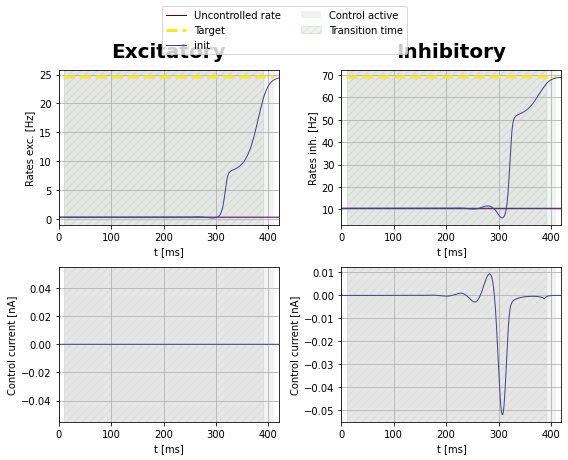

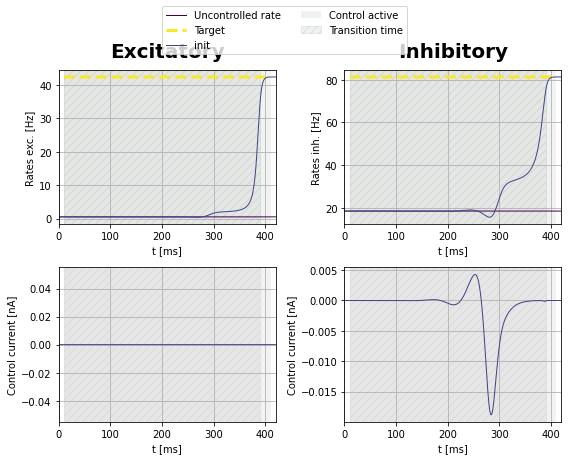

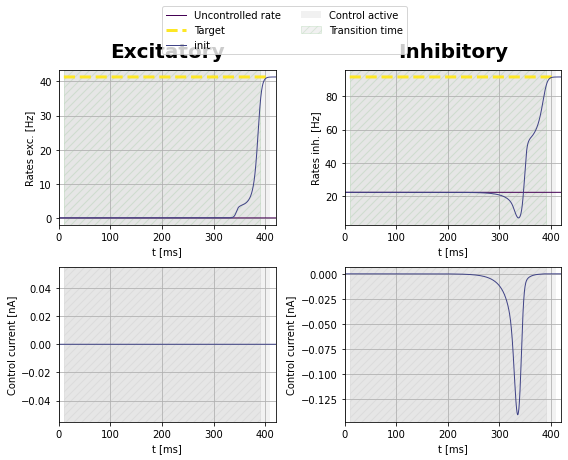

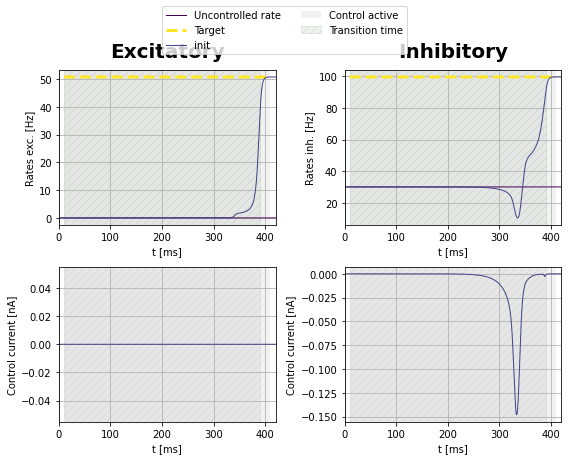

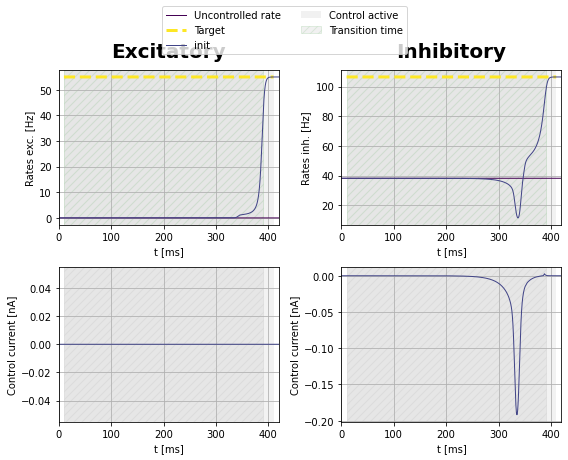

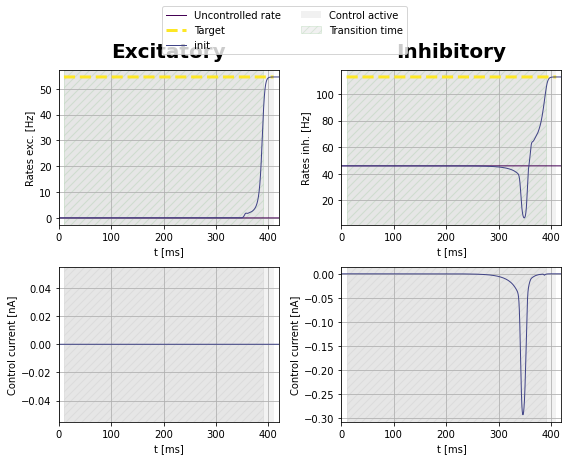

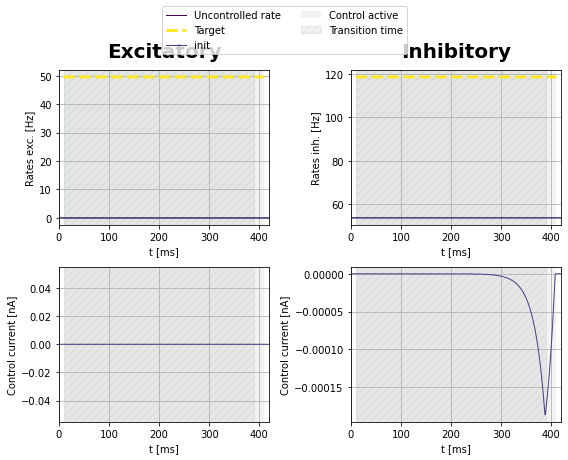

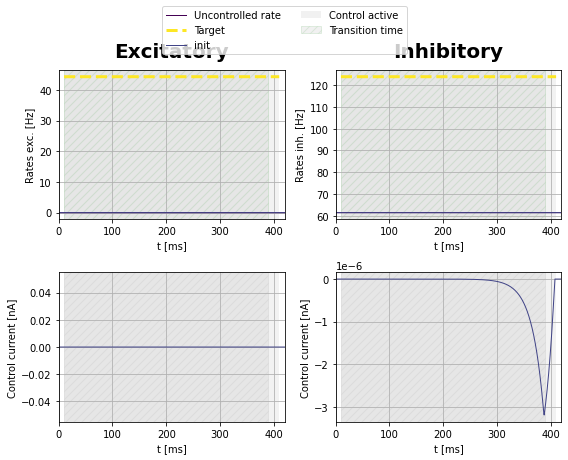

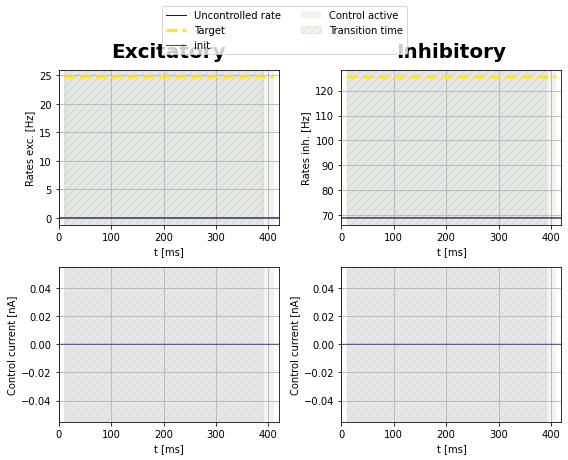

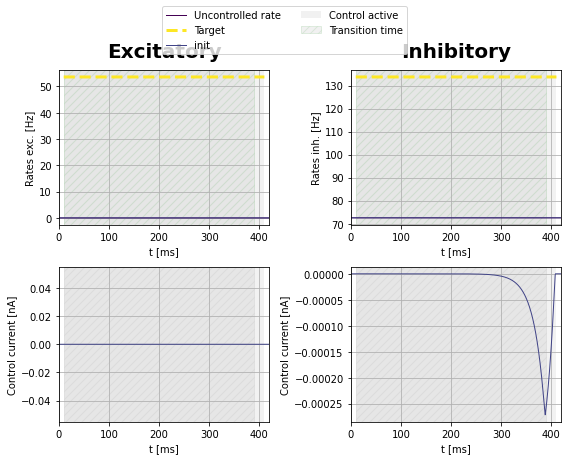

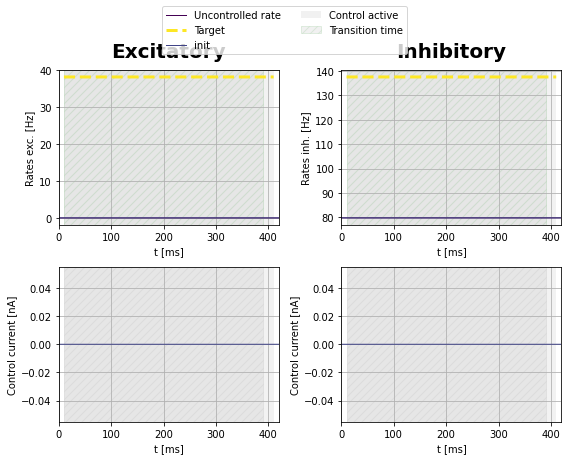

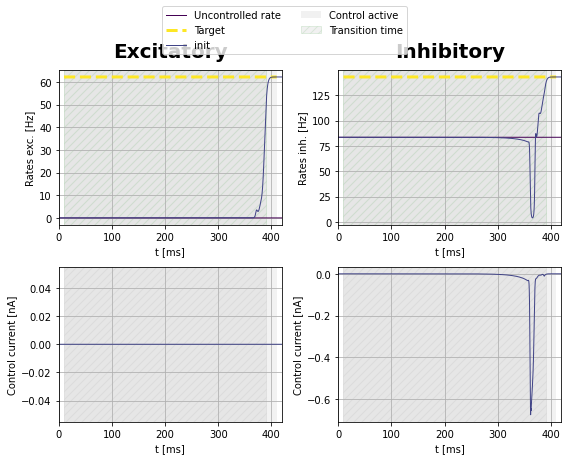

In [15]:
#plot initial guesses

for i in i_range:
        
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i]],
        [costnode_init[i]], [weights_init[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [16]:
found_solution = []
no_solution = []
last_update = -1
factor_iteration = 20.
already_tried = [ [] for _ in range(len(exc)) ]
i_range = range(0, len(exc),i_stepsize)
i_range_0 = []
i_range_1 = []

print(already_tried, len(already_tried))

for k in range(len(i_range)**2):
    print('------------------------------------------------------------')
    print('--------------------', k)
    print('------------------------------------------------------------')
        
    print("found solution: ", found_solution)
    print("no solution: ", no_solution)
    
    if len(i_range) == len(found_solution) + len(no_solution):
        print("found solution for all parameters")
        break
    
    #if last_update != k-1:
    #    print("no improvement from previous step")
    #    break

    for i in i_range:
        print("------- ", i, exc[i], inh[i])

        if np.abs(bestState_init[i][0,0,-1] - target[i][0,0,-1]) < 0.5 * np.abs(
            bestState_init[i][0,0,-1] - bestState_init[i][0,0,0]):
            if i not in found_solution:
                print("found solution for ", i)
                found_solution.append(i)
                #last_update = k
            if i in no_solution:
                no_solution.pop(no_solution.index(i))
            continue

        #if i not in no_solution:
        #    print("no solution for ", i)
        #    no_solution.append(i)
        
        if i not in i_range_0:
            i_range_0.append(i)
            
        if i not in i_range_1:
            i_range_1.append(i)

        closest_ = getclosest(i, found_solution, exc, inh, already_tried[i])
        print("closest index ", closest_)

        weight_ = 10
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
            
        if i != 0 and closest_ != -1:
            control0 = bestControl_init[closest_][:,:,n_pre-1:-n_post+1]
            if closest_ not in already_tried[i]:
                already_tried[i].append(closest_)
                        
        if closest_ == -1:
            print("all options tried already")
            if i not in no_solution:
                no_solution.append(i)
                continue

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(100 * factor_iteration)

        weights_init[i] = cost.getParams()
        
        print("precision vars = ", prec_vars)

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

        j = 1
        while cost_init[i][-j] == 0.:
            j += 1

        weight_ = 10 * cost_uncontrolled[i] / cost_init[i][-j]
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int(500 * factor_iteration)

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)

[[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []] 152
------------------------------------------------------------
-------------------- 0
------------------------------------------------------------
found solution:  []
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
found solution for  0
-------  13 0.47500000000000014 0.40000000000000013
found solution for  13
-------  26 0.47500000000000014 0.4750000000000002
found so

ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  24574.654140984618
RUN  7 , total integrated cost =  24574.654140984618
Control only changes marginally.
RUN  7 , total integrated cost =  24574.654140984618
Improved over  7  iterations in  0.5758018959313631  seconds by  0.3893779555892536  percent.
Problem in initial value trasfer:  Vmean_exc -71.28042999779477 -71.28043741974437
weight =  10.000000035557063
set cost params:  1.0 10.000000035557063 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  24574.654140984618
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  24574.654140984618
Control only changes marginally.
RUN  1 , total integrated cost =  24574.654140984618
Improved over  1  iterations in  0.2632148750126362  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -71.28042999779477 -71.28043741974437
-------  91 0.5000000000000002 0.7250000000000004
[0, 13, 26, 39, 52, 65] []
closest index  65
set cost params:  1.0 10.0 0.0
precision vars =  [0]
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  19707.941538231047
Gradient descend method:  None
RUN  1 , total integrated cost =  19611.762168118254
RUN  2 , total integrated cost =  19611.738760644912
RUN  3 , total integrated cost =  19611.7387549358
RUN  4 , total integrated cost =  19611.738754934355
RUN  5 , total integrated cost =  19611.73875493435
RUN  6 , total integrated cost =  19611.738754934344


...

RUN  15 , total integrated cost =  14227.1935244898
Control only changes marginally.
RUN  15 , total integrated cost =  14227.1935244898
Improved over  15  iterations in  2.1033750269562006  seconds by  1.3690891437071429  percent.
Problem in initial value trasfer:  Vmean_exc -56.67699967203104 -56.67700676400018
-------  143 0.6000000000000003 0.8750000000000006
------------------------------------------------------------
-------------------- 6
------------------------------------------------------------
found solution:  [0, 13, 26, 39, 52, 65, 143, 117, 78, 91]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
-------  52 0.5500000000000003 0.5750000000000003
-------  65 0.5500000000000003 0.6250000000000003
-------  78 0.5250000000000001 0.6750000000000004
-------  91 0.5000000000000002 0.7250000000000004
-------  10

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  47 , total integrated cost =  873.8727436351363
Improved over  47  iterations in  6.157331733033061  seconds by  87.39013345924472  percent.
Problem in initial value trasfer:  Vmean_exc -56.625107634761406 -56.62511080897758
weight =  70.04189345857979
set cost params:  1.0 70.04189345857979 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  6084.123969758152
Gradient descend method:  None
RUN  1 , total integrated cost =  6027.759648074843
RUN  2 , total integrated cost =  6027.734113569481
RUN  3 , total integrated cost =  6027.032590354249
RUN  4 , total integrated cost =  6026.272594562684
RUN  5 , total integrated cost =  6026.255497965783
RUN  6 , total integrated cost =  6026.245102113014
RUN  7 , total integrated cost =  6023.902204419564
RUN  8 , total integrated cost =  6023.894187485434
RUN  9 , total integrated cost =  6023.882911561139
RUN  10 , total integrated cost =  6023.396314158795
RUN  11 , total integra

ERROR:root:Problem in initial value trasfer


RUN  20 , total integrated cost =  6023.25855308717
Control only changes marginally.
RUN  21 , total integrated cost =  6023.25855308717
Improved over  21  iterations in  2.698427362367511  seconds by  1.0003973780534494  percent.
Problem in initial value trasfer:  Vmean_exc -56.62401449079294 -56.62402398322457
-------  117 0.5500000000000003 0.8000000000000005
-------  130 0.47500000000000014 0.8500000000000005
-------  143 0.6000000000000003 0.8750000000000006
------------------------------------------------------------
-------------------- 8
------------------------------------------------------------
found solution:  [0, 13, 26, 39, 52, 65, 143, 117, 78, 91, 130]
no solution:  []
-------  0 0.4000000000000001 0.3500000000000001
-------  13 0.47500000000000014 0.40000000000000013
-------  26 0.47500000000000014 0.4750000000000002
-------  39 0.5250000000000001 0.5250000000000002
-------  52 0.5500000000000003 0.5750000000000003
-------  65 0.5500000000000003 0.6250000000000003
----

In [17]:
factor_iteration = 20
full_converge = False
conv_init = [[False]*2] * len(exc)

for i in range(len(conv_init)):
    if i not in i_range:
        conv_init[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    if counter > 100:
        break
        
    print(conv_init[::i_stepsize])
    full_converge = True
    
    for conv in conv_init[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_init[i][-j] == 0.:
            j += 1
            
        if j == cost_init[i].shape[0]-1:
            print("converged for ", i)
            if conv_init[i][0]:
                conv_init[i] = [True, True]
            else:
                conv_init[i] = [True, False]
            continue
    
        print("no convergence")
            
        weight_ = (factor_we * weights_init[i][1] * cost_uncontrolled[i] / cost_init[i][-j]
                   + factor_ws * weights_init[i][2] * cost_uncontrolled[i] / cost_init[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_init[i] = cost.getParams()

        bestControl_init[i], bestState_init[i], cost_init[i], runtime_init[i], grad_init[i], phi_init[i], costnode_init[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  13067.897733254276
set cost params:  1.0 13067.897733254276 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5898.829636795645
Gradient descend method:  None
RUN  1 , total integrated cost =  5898.748636765379
RUN  2 , total integrated cost =  5898.747665213656
RUN  3 , total integrated cost =  5898.747622372383
RUN  4 , total integrated cost =  5898.747619094501
RUN  5 , total integrated cost =  5898.747618777083
RUN  6 , total integrated cost =  5898.747618738525
RUN  7 , total integrated cost =  5898.747618734368
RUN  8 , total integrated cost =  5898.747618734003
RUN  9 , total integrated cost =  5898.747618733932


ERROR:root:Problem in initial value trasfer


RUN  10 , total integrated cost =  5898.747618733932
Control only changes marginally.
RUN  10 , total integrated cost =  5898.747618733932
Improved over  10  iterations in  1.4962512962520123  seconds by  0.0013904124506467497  percent.
Problem in initial value trasfer:  Vmean_exc -56.62673003497232 -56.626736778748395
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  206134.83993372676
set cost params:  1.0 206134.83993372676 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17549.402563494532
Gradient descend method:  None
RUN  1 , total integrated cost =  17549.388644202223
RUN  2 , total integrated cost =  17549.38854672013
RUN  3 , total integrated cost =  17549.38854672005
RUN  4 , total integrated cost =  17549.38854672002
RUN  5 , total integrated cost =  17549.388546720016


ERROR:root:Problem in initial value trasfer


RUN  6 , total integrated cost =  17549.388546720016
Control only changes marginally.
RUN  6 , total integrated cost =  17549.388546720016
Improved over  6  iterations in  1.3491713721305132  seconds by  7.98703800057865e-05  percent.
Problem in initial value trasfer:  Vmean_exc -56.690632503072415 -56.690633556780135
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  4896.74404041032
set cost params:  1.0 4896.74404041032 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17063.414281528243
Gradient descend method:  None
RUN  1 , total integrated cost =  17063.39079778379
RUN  2 , total integrated cost =  17063.39077798594
RUN  3 , total integrated cost =  17063.390777740802
RUN  4 , total integrated cost =  17063.39077774022
RUN  5 , total integrated cost =  17063.390777740195
RUN  6 , total integrated cost =  17063.390777740176


...

RUN  1 , total integrated cost =  6034.776548366685
Control only changes marginally.
RUN  1 , total integrated cost =  6034.776548366685
Improved over  1  iterations in  0.3321581110358238  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62401393698668 -56.62402343363036
-------  117 0.5500000000000003 0.8000000000000005
no convergence
weight =  801.8198820562552
set cost params:  1.0 801.8198820562552 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  28679.773480607964
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  28679.773480607964
Control only changes marginally.
RUN  1 , total integrated cost =  28679.773480607964
Improved over  1  iterations in  0.3477465249598026  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70408197190381 -56.704082014558445
-------  130 0.47500000000000014 0.8500000000000005
no convergence
weight =  177.57122359516953
set cost params:  1.0 177.57122359516953 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14466.510267201158
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  14466.510267201158
Control only changes marginally.
RUN  1 , total integrated cost =  14466.510267201158
Improved over  1  iterations in  0.33889715000987053  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67699660627759 -56.67700377224645
-------  143 0.6000000000000003 0.8750000000000006
converged for  143
[[True, True], [True, True], [False, False], [True, True], [True, True], [True, False], [True, True], [False, False], [False, False], [False, False], [False, False], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.5250000000000001 0.675000

In [18]:
print(conv_init[::i_stepsize])

with open(init_file,'wb') as f:
    pickle.dump([bestControl_init, bestState_init, cost_init, runtime_init, grad_init, phi_init,
                 costnode_init, weights_init], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [19]:
if os.path.isfile(final_file) :
    print("file found")
    
    with open(final_file,'rb') as f:
        load_array = pickle.load(f)

    bestControl_0 = load_array[0]
    bestState_0 = load_array[1]
    cost_0 = load_array[2]
    runtime_0 = load_array[3]
    grad_0 = load_array[4]
    phi_0 = load_array[5]
    costnode_0 = load_array[6]
    weights_0 = load_array[7]

In [20]:
i_range_0 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_0:
    if type(bestControl_0[i]) == type(None):
        i_range_.append(i)

i_range_0 = np.array(i_range_)
        
print(i_range_0)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [21]:
factor_iteration = 20
    
for i in i_range_0:
    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

# exc and inh control current 

    setinit(initVars[i], aln)
    aln.params.duration = dur
    control0 = bestControl_init[i][:,:,n_pre-1:-n_post+1].copy()
    #control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]
 
    cost.setParams(1.0, 0.0, 10.0)

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = "HS"
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)
    
    j = 1
    while cost_0[i][-j] == 0.:
        j += 1
    
    weight_ = 100 * cost_uncontrolled[i] / cost_0[i][-j] - 1
    print("weight = ", weight_)
    cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = 50 * factor_iteration

    weights_0[i] = cost.getParams()

    bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  51.397822455133046
Gradient descend method:  None
RUN  1 , total integrated cost =  9.985039374337294
RUN  2 , total integrated cost =  9.933823559729925
RUN  3 , total integrated cost =  9.912529098753941
RUN  4 , total integrated cost =  9.872952935800814
RUN  5 , total integrated cost =  9.859436277415877
RUN  6 , total integrated cost =  9.857399382958683
RUN  7 , total integrated cost =  9.856957731662964
RUN  8 , total integrated cost =  9.856184908095358
RUN  9 , total integrated cost =  9.85590132819908
RUN  10 , total integrated cost =  9.855566683007622
RUN  11 , total integrated cost =  9.855434110303081
RUN  12 , total integrated cost =  9.854614740077109
RUN  13 , total integrated cost =  9.853744392576125
RUN  14 , total integrated cost =  9.853680760619696
RUN  15 , total integrated cost =  9.852865866306036
RUN  16 , tot

ERROR:root:Problem in initial value trasfer


RUN  80 , total integrated cost =  9.837836555390892
Control only changes marginally.
RUN  80 , total integrated cost =  9.837836555390892
Improved over  80  iterations in  18.030914032831788  seconds by  80.85942928033832  percent.
Problem in initial value trasfer:  Vmean_exc -56.627621138015535 -56.62762110597136
weight =  100
set cost params:  1.0 100.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  46.45300062815396
Gradient descend method:  HS
RUN  1 , total integrated cost =  45.86886283459039
RUN  2 , total integrated cost =  45.75367871678472
RUN  3 , total integrated cost =  45.39958412074481
RUN  4 , total integrated cost =  44.918446672956165
RUN  5 , total integrated cost =  44.855282182513626
RUN  6 , total integrated cost =  44.78301293000065
RUN  7 , total integrated cost =  44.62873069268953
RUN  8 , total integrated cost =  44.526206044236
RUN  9 , total integrated cost =  44.19020677447062
RUN  10 , total integrated cost =  44.137984826895

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  942 , total integrated cost =  29.53111125087794
Improved over  942  iterations in  203.47838797979057  seconds by  36.42797913687431  percent.
Problem in initial value trasfer:  Vmean_exc -56.627598254713476 -56.62759852522365
weight =  19986.07881019177
set cost params:  1.0 19986.07881019177 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5898.466594730681
Gradient descend method:  None
RUN  1 , total integrated cost =  5862.458501355567
RUN  2 , total integrated cost =  5861.600762332962
RUN  3 , total integrated cost =  5861.151072909817
RUN  4 , total integrated cost =  5859.900329104442
RUN  5 , total integrated cost =  5858.306977773658
RUN  6 , total integrated cost =  5857.228958919868
RUN  7 , total integrated cost =  5855.811616321167
RUN  8 , total integrated cost =  5855.042543898308
RUN  9 , total integrated cost =  5854.210533760626
RUN  10 , total integrated cost =  5853.226000427799
RUN  11 , total inte

...

Control only changes marginally.
RUN  279 , total integrated cost =  5422.793710997597
Improved over  279  iterations in  47.81614906899631  seconds by  62.42472283340178  percent.
Problem in initial value trasfer:  Vmean_exc -56.67729716340768 -56.677297101506085
-------  143 0.6000000000000003 0.8750000000000006
set cost params:  1.0 0.0 10.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1111.6722943311204
Gradient descend method:  None
RUN  1 , total integrated cost =  79.51267589001307
RUN  2 , total integrated cost =  78.34164567944067
RUN  3 , total integrated cost =  77.9186043241421
RUN  4 , total integrated cost =  77.85549846716766
RUN  5 , total integrated cost =  77.78888475566609
RUN  6 , total integrated cost =  77.71346341609441
RUN  7 , total integrated cost =  77.66101084622827
RUN  8 , total integrated cost =  77.60621744631422
RUN  9 , total integrated cost =  77.55832124524433
RUN  10 , total integrated cost =  77.5147594766118
RUN  11 , to

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  402 , total integrated cost =  74.0511350994381
Improved over  402  iterations in  71.97517223656178  seconds by  30.33459803607917  percent.
Problem in initial value trasfer:  Vmean_exc -56.70027230559886 -56.70027254209858
weight =  52142.71383144672
set cost params:  1.0 52142.71383144672 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  38607.613232110496
Gradient descend method:  None
RUN  1 , total integrated cost =  38533.51636149231
RUN  2 , total integrated cost =  38533.31406192817
RUN  3 , total integrated cost =  38533.31319808489
RUN  4 , total integrated cost =  38533.28306725638
RUN  5 , total integrated cost =  38533.26224263411
RUN  6 , total integrated cost =  38533.26155106459
RUN  7 , total integrated cost =  38533.23790359736
RUN  8 , total integrated cost =  38533.22158085983
RUN  9 , total integrated cost =  38533.220884762704
RUN  10 , total integrated cost =  38533.20096238125
RUN  11 , total integ

ERROR:root:Problem in initial value trasfer


RUN  101 , total integrated cost =  38521.0106871375
Improved over  101  iterations in  17.968434002250433  seconds by  0.2243146823201272  percent.
Problem in initial value trasfer:  Vmean_exc -56.70027359809512 -56.70027373104053


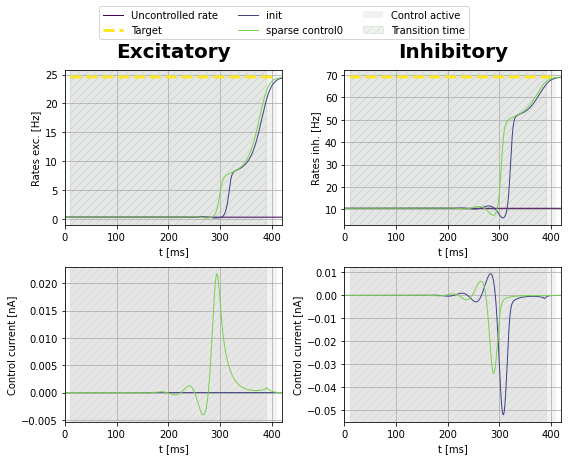

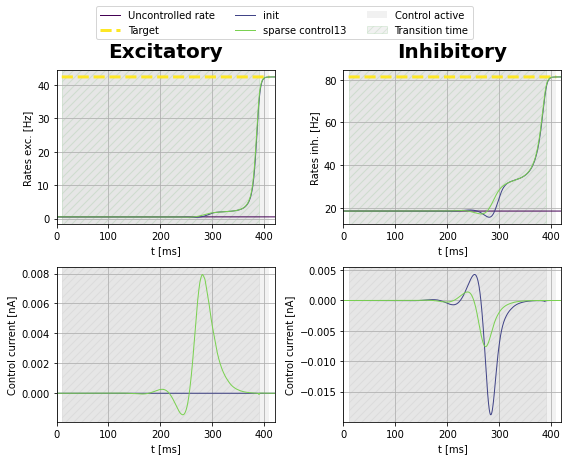

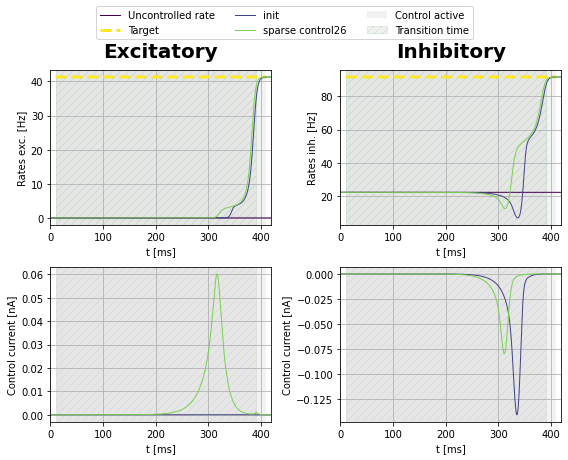

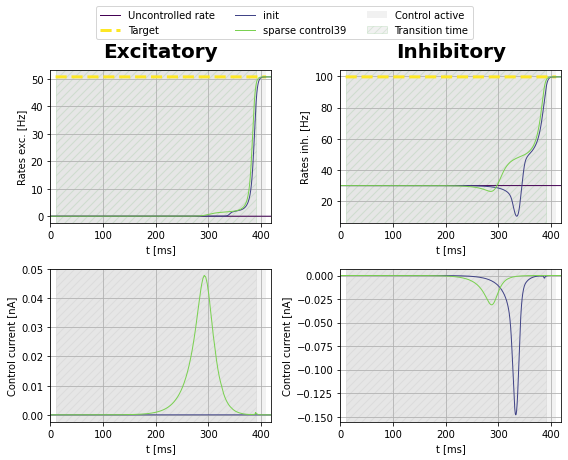

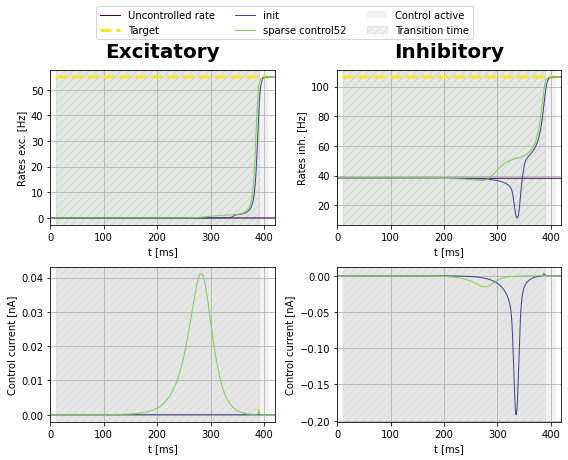

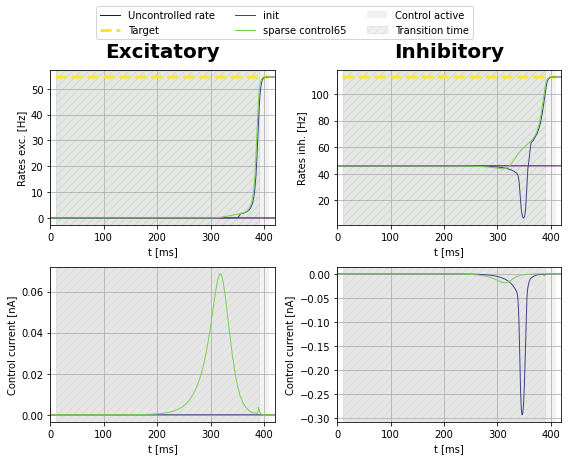

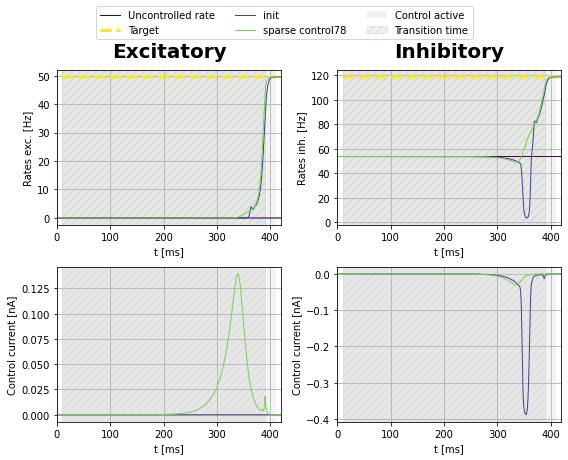

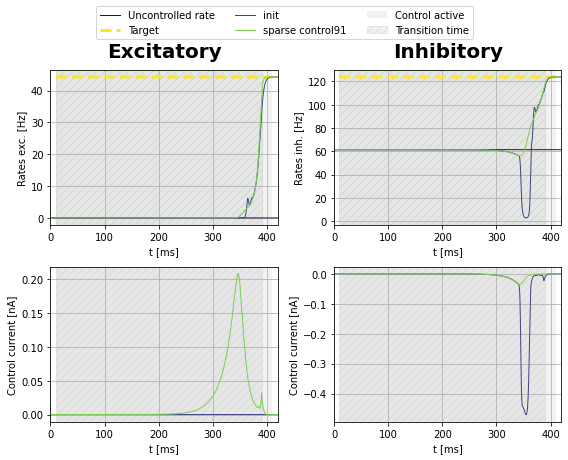

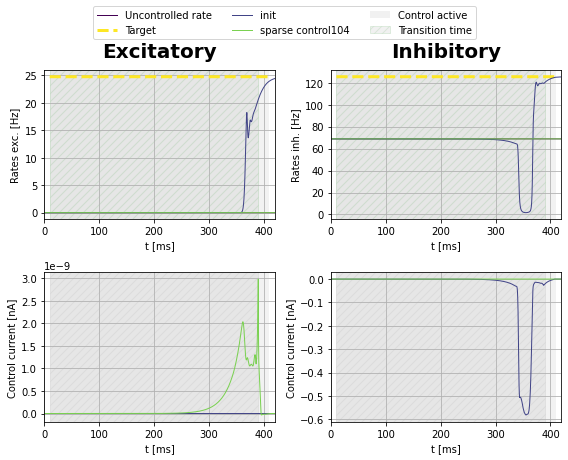

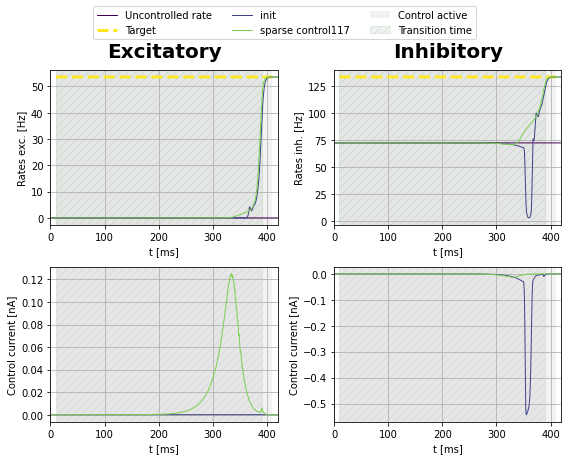

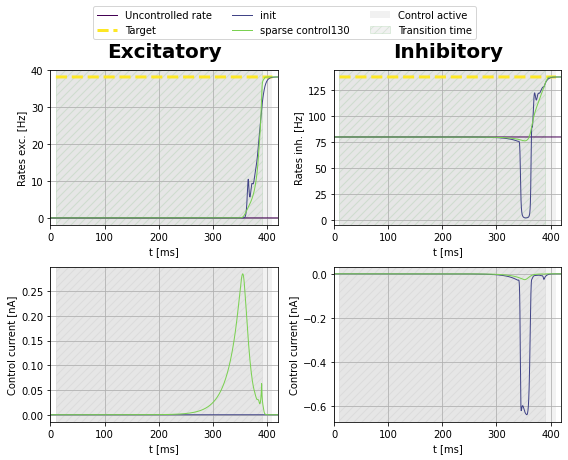

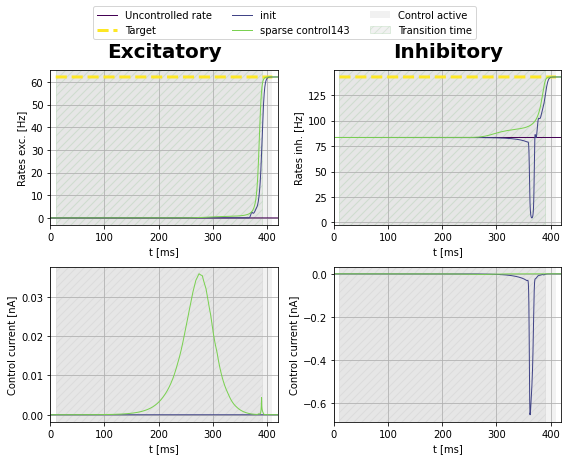

In [22]:
for i in i_range_0:
    
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    plotFunc.plot_control_current(aln, [bestControl_init[i], bestControl_0[i]],
        [costnode_init[i], costnode_0[i]], [weights_init[i], weights_0[i]], dur,
        dur_pre, dur_post, initVars[i], target[i], '', filename_ = '', transition_time_ = trans_time,
        labels_ = ["init", "sparse control" + str(i)], print_cost_ = False)

In [23]:
factor_iteration = 20
full_converge = False
conv_0 = [[False]*2] * len(exc)

for i in range(len(conv_0)):
    if i not in i_range_0:
        conv_0[i] = [True, True]

counter = 0

while full_converge == False:
    print('---------------', counter)
    
    if counter > 100:
        break
    
    print(conv_0[::i_stepsize])
    full_converge = True
    
    for conv in conv_0[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_0:

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.

        j = 1
        while cost_0[i][-j] == 0.:
            j += 1
            
        if j == cost_0[i].shape[0]-1:
            print("converged for ", i)
            if conv_0[i][0]:
                conv_0[i] = [True, True]
            else:
                conv_0[i] = [True, False]
            continue
    
        print("no convergence")

        weight_ = (factor_we * weights_0[i][1] * cost_uncontrolled[i] / cost_0[i][-j]
                       + factor_ws * weights_0[i][2] * cost_uncontrolled[i] / cost_0[i][-j]) - 1
        print("weight = ", weight_)
        cost.setParams(1.0, weight_ * factor_we, weight_ * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = 500 * factor_iteration

        weights_0[i] = cost.getParams()

        bestControl_0[i], bestState_0[i], cost_0[i], runtime_0[i], grad_0[i], phi_0[i], costnode_0[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_0,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
    counter += 1
    

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
weight =  20498.36480200746
set cost params:  1.0 20498.36480200746 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5901.789240801703
Gradient descend method:  None
RUN  1 , total integrated cost =  5901.785535532903
RUN  2 , total integrated cost =  5901.776418021645
RUN  3 , total integrated cost =  5901.767247995459
RUN  4 , total integrated cost =  5901.767237687219
RUN  5 , total integrated cost =  5901.758854584978
RUN  6 , total integrated cost =  5901.750298379493
RUN  7 , total integrated cost =  5901.750295504672
RUN  8 , total integrated cost =  5901.7422001145005
RUN  9 , total integrated cost =  5901.734977842472
RUN  10 , total integrated cost =  5901.726515254372
RUN  11 , 

ERROR:root:Problem in initial value trasfer


RUN  19 , total integrated cost =  5901.704143210252
Control only changes marginally.
RUN  19 , total integrated cost =  5901.704143210252
Improved over  19  iterations in  4.523676861077547  seconds by  0.0014418947878169774  percent.
Problem in initial value trasfer:  Vmean_exc -56.627155337894386 -56.62715993112191
-------  13 0.47500000000000014 0.40000000000000013
no convergence
weight =  456121.31943913066
set cost params:  1.0 456121.31943913066 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17549.117315234118
Gradient descend method:  None
RUN  1 , total integrated cost =  17549.077207832233
RUN  2 , total integrated cost =  17549.076463521666
RUN  3 , total integrated cost =  17549.076414601466
RUN  4 , total integrated cost =  17549.07640940506
RUN  5 , total integrated cost =  17549.076409285448
RUN  6 , total integrated cost =  17549.076409285302
RUN  7 , total integrated cost =  17549.0764092853


ERROR:root:Problem in initial value trasfer


RUN  8 , total integrated cost =  17549.0764092853
Control only changes marginally.
RUN  8 , total integrated cost =  17549.0764092853
Improved over  8  iterations in  2.481684086844325  seconds by  0.0002330940530157477  percent.
Problem in initial value trasfer:  Vmean_exc -56.69063874851399 -56.690639591940624
-------  26 0.47500000000000014 0.4750000000000002
no convergence
weight =  8279.167242150603
set cost params:  1.0 8279.167242150603 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  17066.762293808944
Gradient descend method:  None
RUN  1 , total integrated cost =  17066.762293808923
RUN  2 , total integrated cost =  17066.762293808915


...

RUN  1 , total integrated cost =  28710.243149493795
Control only changes marginally.
RUN  1 , total integrated cost =  28710.243149493795
Improved over  1  iterations in  0.49912156350910664  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70408199272187 -56.70408207449092
-------  130 0.47500000000000014 0.8500000000000005
no convergence
weight =  670.0592207845538
set cost params:  1.0 670.0592207845538 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  14526.299914911659
Gradient descend method:  None
RUN  1 , total integrated cost =  14526.299914911655


ERROR:root:Problem in initial value trasfer


RUN  2 , total integrated cost =  14526.299914911655
Control only changes marginally.
RUN  2 , total integrated cost =  14526.299914911655
Improved over  2  iterations in  0.9221115410327911  seconds by  2.842170943040401e-14  percent.
Problem in initial value trasfer:  Vmean_exc -56.67728699068182 -56.677286740639126
-------  143 0.6000000000000003 0.8750000000000006
converged for  143
--------------- 7
[[True, True], [True, True], [True, True], [True, True], [True, True], [False, False], [False, False], [False, False], [True, True], [False, False], [False, False], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
----

ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  14526.299914911655
Control only changes marginally.
RUN  1 , total integrated cost =  14526.299914911655
Improved over  1  iterations in  0.48498724214732647  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.67728699068182 -56.677286740639126
-------  143 0.6000000000000003 0.8750000000000006
converged for  143
--------------- 8
[[True, True], [True, True], [True, True], [True, True], [True, True], [True, False], [True, False], [True, False], [True, True], [True, False], [False, False], [True, True]]
-------  0 0.4000000000000001 0.3500000000000001
converged for  0
-------  13 0.47500000000000014 0.40000000000000013
converged for  13
-------  26 0.47500000000000014 0.4750000000000002
converged for  26
-------  39 0.5250000000000001 0.5250000000000002
converged for  39
-------  52 0.5500000000000003 0.5750000000000003
converged for  52
-------  65 0.5500000000000003 0.6250000000000003
converged for  65
-------  78 0.52500000000

In [24]:
print(conv_0[::i_stepsize])

with open(final_file,'wb') as f:
    pickle.dump([bestControl_0, bestState_0, cost_0, runtime_0, grad_0, phi_0,
                 costnode_0, weights_0], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]


In [25]:
bestControl_1 = [None] * len(exc)
bestState_1 = [None] * len(exc)
cost_1 = [None] * len(exc)
runtime_1 = [None] * len(exc)
grad_1 = [None] * len(exc)
phi_1 = [None] * len(exc)
costnode_1 = [None] * len(exc)
weights_1 = [None] * len(exc)

conv_1 = [[False]*2] * len(exc)

In [26]:
if os.path.isfile(final_file_1) :
    print("file found")
    
    with open(final_file_1,'rb') as f:
        load_array = pickle.load(f)

    bestControl_1 = load_array[0]
    bestState_1 = load_array[1]
    cost_1 = load_array[2]
    runtime_1 = load_array[3]
    grad_1 = load_array[4]
    phi_1 = load_array[5]
    costnode_1 = load_array[6]
    weights_1 = load_array[7]

In [27]:
i_range_1 = range(0, len(exc),i_stepsize)
i_range_ = []

for i in i_range_1:
    if type(bestControl_1[i]) == type(None):
        i_range_.append(i)

i_range_1 = np.array(i_range_)  

print(i_range_1)

[  0  13  26  39  52  65  78  91 104 117 130 143]


In [28]:
factor_iteration = 20

for i in i_range_1:        

    print("------- ", i, exc[i], inh[i])
    aln.params.mue_ext_mean = exc[i] * 5.
    aln.params.mui_ext_mean = inh[i] * 5.

    cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

    setinit(initVars[i], aln)
    control0 = bestControl_0[i][:,:,n_pre-1:-n_post+1]

    # "HS", "FR", "PR", "HZ"
    cgv = None
    max_it = int( 500 * factor_iteration )

    weights_1[i] = cost.getParams()

    bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
        control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
        startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
        t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
        prec_variables_ = prec_vars, transition_time_ = trans_time)

-------  0 0.4000000000000001 0.3500000000000001
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13.482678460765381
Gradient descend method:  None
RUN  1 , total integrated cost =  0.32410054762032375
RUN  2 , total integrated cost =  0.323727512723163
RUN  3 , total integrated cost =  0.3235571921555038
RUN  4 , total integrated cost =  0.3232713660373011
RUN  5 , total integrated cost =  0.3230665242988564
RUN  6 , total integrated cost =  0.32231182051772655
RUN  7 , total integrated cost =  0.321596223533864
RUN  8 , total integrated cost =  0.3186038858425312
RUN  9 , total integrated cost =  0.3152979303320672
RUN  10 , total integrated cost =  0.3137207892560756
RUN  11 , total integrated cost =  0.31235944531068766
RUN  12 , total integrated cost =  0.3118797347299298
RUN  13 , total integrated cost =  0.31136799931434866
RUN  14 , total integrated cost =  0.31123896753357383
RUN  15 , total integrated cost =  0.311065660747

ERROR:root:Problem in initial value trasfer


RUN  120 , total integrated cost =  0.2958033377859175
Control only changes marginally.
RUN  121 , total integrated cost =  0.2958033377859175
Improved over  121  iterations in  8.39744228310883  seconds by  97.80604915672575  percent.
Problem in initial value trasfer:  Vmean_exc -56.62761758497342 -56.62761765605284
-------  13 0.47500000000000014 0.40000000000000013
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  34.96857742376375
Gradient descend method:  None
RUN  1 , total integrated cost =  0.04018293670963123
RUN  2 , total integrated cost =  0.04015190515592154
RUN  3 , total integrated cost =  0.04010921861754491
RUN  4 , total integrated cost =  0.040073819883581774
RUN  5 , total integrated cost =  0.04000952387611329
RUN  6 , total integrated cost =  0.039961036095588744
RUN  7 , total integrated cost =  0.03992329778892204
RUN  8 , total integrated cost =  0.039898140968185
RUN  9 , total integrated cost =  0.0398953981

ERROR:root:Problem in initial value trasfer


RUN  130 , total integrated cost =  2.0771119042040493
Control only changes marginally.
RUN  130 , total integrated cost =  2.0771119042040493
Improved over  130  iterations in  9.182213995605707  seconds by  84.09705402169467  percent.
Problem in initial value trasfer:  Vmean_exc -56.687522863674936 -56.68752289954851
-------  39 0.5250000000000001 0.5250000000000002
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  10.4807062037782
Gradient descend method:  None
RUN  1 , total integrated cost =  1.1901920635310614
RUN  2 , total integrated cost =  1.1901894655218022
RUN  3 , total integrated cost =  1.1901886717348171
RUN  4 , total integrated cost =  1.1894841526449866
RUN  5 , total integrated cost =  1.1893386705474405
RUN  6 , total integrated cost =  1.1893385230328706
RUN  7 , total integrated cost =  1.1893385198575803
RUN  8 , total integrated cost =  1.1893385195747086
RUN  9 , total integrated cost =  1.1893385195388344
RU

...

Control only changes marginally.
RUN  21 , total integrated cost =  5.502778212174235
Improved over  21  iterations in  1.5918489955365658  seconds by  92.08293381709724  percent.
Problem in initial value trasfer:  Vmean_exc -56.70408263187471 -56.70408266871423
-------  130 0.47500000000000014 0.8500000000000005
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  53.46192653329682
Gradient descend method:  None
RUN  1 , total integrated cost =  24.366760737830102
RUN  2 , total integrated cost =  24.360073344035335
RUN  3 , total integrated cost =  24.322874586033237
RUN  4 , total integrated cost =  24.28763192620226
RUN  5 , total integrated cost =  24.231533688739773
RUN  6 , total integrated cost =  24.179043571069705
RUN  7 , total integrated cost =  24.17675450325996
RUN  8 , total integrated cost =  24.172765136246262
RUN  9 , total integrated cost =  24.17032723263857
RUN  10 , total integrated cost =  24.163778374291123
RUN  1

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  85 , total integrated cost =  23.66916827614844
Improved over  85  iterations in  5.912225654348731  seconds by  55.72705697126916  percent.
Problem in initial value trasfer:  Vmean_exc -56.677340314845765 -56.67733930994059
-------  143 0.6000000000000003 0.8750000000000006
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  20.108869617557044
Gradient descend method:  None
RUN  1 , total integrated cost =  0.7434787339558613
RUN  2 , total integrated cost =  0.7425544189433365
RUN  3 , total integrated cost =  0.7425529286675772
RUN  4 , total integrated cost =  0.7425297376542533
RUN  5 , total integrated cost =  0.7425080523087301
RUN  6 , total integrated cost =  0.742496263034278
RUN  7 , total integrated cost =  0.7424842668487489
RUN  8 , total integrated cost =  0.742484017134779
RUN  9 , total integrated cost =  0.7424828856883031
RUN  10 , total integrated cost =  0.7424821317183699
RUN  

ERROR:root:Problem in initial value trasfer


Control only changes marginally.
RUN  106 , total integrated cost =  0.7423255182377491
Improved over  106  iterations in  7.704502006992698  seconds by  96.30846719703416  percent.
Problem in initial value trasfer:  Vmean_exc -56.70027376514293 -56.700273875258546


In [29]:
factor_iteration = 20
full_converge = False

for i in range(len(conv_1)):
    if i not in i_range_1:
        conv_1[i] = [True, True]
        
counter = 0

while full_converge == False:
    
    print('---------------', counter)
    
    print(conv_1[::i_stepsize])
    full_converge = True
    
    for conv in conv_1[::i_stepsize]:
        if not conv[0]:
            full_converge = False
            break
        if not conv[1]:
            full_converge = False
            break
    
    if full_converge:
        print("full convergence")
        break

    for i in i_range_1:        

        print("------- ", i, exc[i], inh[i])
        aln.params.mue_ext_mean = exc[i] * 5.
        aln.params.mui_ext_mean = inh[i] * 5.
        
        j = 1
        while cost_1[i][-j] == 0.:
            j += 1
            
        if j == cost_1[i].shape[0]-1:
            print("converged for ", i)
            if conv_1[i][0]:
                conv_1[i] = [True, True]
            else:
                conv_1[i] = [True, False]
            continue
    
        print("no convergence")
        
        cost.setParams(1.0, 1. * factor_we, 1. * factor_ws)

        setinit(initVars[i], aln)
        control0 = bestControl_1[i][:,:,n_pre-1:-n_post+1]

        # "HS", "FR", "PR", "HZ"
        cgv = None
        max_it = int( 500 * factor_iteration )

        weights_1[i] = cost.getParams()

        bestControl_1[i], bestState_1[i], cost_1[i], runtime_1[i], grad_1[i], phi_1[i], costnode_1[i] = aln.A1(
            control0, target[i], c_scheme, u_mat, u_scheme, max_iteration_ = max_it, tolerance_ = tol,
            startStep_ = start_step, max_control_ = max_cntrl, min_control_ = min_cntrl, t_sim_ = dur,
            t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv, control_variables_ = cntrl_vars_init,
            prec_variables_ = prec_vars, transition_time_ = trans_time)
        
        counter += 1

--------------- 0
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False]]
-------  0 0.4000000000000001 0.3500000000000001
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.2958033377859175
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  0.2958033377859175
Control only changes marginally.
RUN  1 , total integrated cost =  0.2958033377859175
Improved over  1  iterations in  0.1661495864391327  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.62761758497342 -56.62761765605284
-------  13 0.47500000000000014 0.40000000000000013
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.03979452225682545
Gradient descend method:  None
RUN  1 , total integrated cost =  0.03979452225682545
Control only changes marginally.
RUN  1 , total integrated cost =  0.03979452225682545
Improved over  1  iterations in  0.1621930468827486  seconds by  0.0  percent.
-------  26 0.47500000000000014 0.4750000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  2.0771119042040493
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  2.0771119042040493
Control only changes marginally.
RUN  1 , total integrated cost =  2.0771119042040493
Improved over  1  iterations in  0.17246882058680058  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.687522863674936 -56.68752289954851
-------  39 0.5250000000000001 0.5250000000000002
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  1.1893385195308324
Gradient descend method:  None
RUN  1 , total integrated cost =  1.1893385195308324
Control only changes marginally.
RUN  1 , total integrated cost =  1.1893385195308324
Improved over  1  iterations in  0.1659329179674387  seconds by  0.0  percent.
-------  52 0.5500000000000003 0.5750000000000003
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.9270792357081226
Gradient descend method:  None
RUN  1 , total integrated cost =  0.927079235

...

RUN  1 , total integrated cost =  6.740019217289653
Control only changes marginally.
RUN  1 , total integrated cost =  6.740019217289653
Improved over  1  iterations in  0.1707598753273487  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.701922590280674 -56.7019225742501
-------  91 0.5000000000000002 0.7250000000000004
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  13.399059203586772
Gradient descend method:  None
RUN  1 , total integrated cost =  13.399059203586772
Control only changes marginally.
RUN  1 , total integrated cost =  13.399059203586772
Improved over  1  iterations in  0.17062084935605526  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.694078912432026 -56.69407964240506
-------  104 0.4250000000000001 0.7750000000000005
converged for  104
-------  117 0.5500000000000003 0.8000000000000005
no convergence
set cost params:  1.0 1.0 0.0


ERROR:root:Problem in initial value trasfer


interpolate adjoint :  True True True
RUN  0 , total integrated cost =  5.502778212174235
Gradient descend method:  None
RUN  1 , total integrated cost =  5.502778212174235
Control only changes marginally.
RUN  1 , total integrated cost =  5.502778212174235
Improved over  1  iterations in  0.16420013643801212  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70408263187471 -56.70408266871423
-------  130 0.47500000000000014 0.8500000000000005
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  23.66916827614844
Gradient descend method:  None


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  23.66916827614844
Control only changes marginally.
RUN  1 , total integrated cost =  23.66916827614844
Improved over  1  iterations in  0.1731532271951437  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.677340314845765 -56.67733930994059
-------  143 0.6000000000000003 0.8750000000000006
no convergence
set cost params:  1.0 1.0 0.0
interpolate adjoint :  True True True
RUN  0 , total integrated cost =  0.7423255182377491
Gradient descend method:  None
RUN  1 , total integrated cost =  0.7423255182377491
Control only changes marginally.
RUN  1 , total integrated cost =  0.7423255182377491
Improved over  1  iterations in  0.1586687285453081  seconds by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -56.70027376514293 -56.700273875258546
--------------- 11
[[False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [False, False], [True, False], [False, False], [

In [30]:
print(conv_1[::i_stepsize])

with open(final_file_1,'wb') as f:
    pickle.dump([bestControl_1, bestState_1, cost_1, runtime_1, grad_1, phi_1,
                 costnode_1, weights_1], f)

[[True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True], [True, True]]
